# Aggregation Trading Plotting

This notebook reads the compact plotting tables generated from Caliper results and draws the main performance and threshold sensitivity figures. It does not parse raw Caliper logs.

## 1. Load Data

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'experiments').exists():
    # If the notebook is opened from experiments/aggregation_trading/analysis
    ROOT = Path.cwd().parents[2]

PROCESSED_DIR = ROOT / 'experiments' / 'aggregation_trading' / 'results' / 'processed'
FIGURES_DIR = ROOT / 'experiments' / 'aggregation_trading' / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

main_path = PROCESSED_DIR / 'main绘图.xlsx'
sensitivity_path = PROCESSED_DIR / 'sensitivity绘图.xlsx'

main_df = pd.read_excel(main_path, sheet_name='main_plot')
sensitivity_df = pd.read_excel(sensitivity_path, sheet_name='sensitivity_plot')

display(main_df.head())
display(sensitivity_df.head())

,series,case,aggregation,workload,threshold,request_size,n_runs,repeats,succ_mean,fail_mean,success_rate_mean,throughput_tps_mean,throughput_tps_ci95,avg_latency_s_mean,avg_latency_s_ci95
0,Trading (no aggregation),no_aggregation,False,trading,NaN,100,3,"1,2,3",2000.0,0.0,1.0,95.300000,7.161619,0.923333,1.400368
1,Trading (no aggregation),no_aggregation,False,trading,NaN,300,3,"1,2,3",2000.0,0.0,1.0,54.033333,6.315955,13.526667,1.350789
2,Trading (no aggregation),no_aggregation,False,trading,NaN,500,3,"1,2,3",2000.0,0.0,1.0,32.833333,2.747787,31.210000,4.137822
3,Trading (no aggregation),no_aggregation,False,trading,NaN,700,3,"1,2,3",2000.0,0.0,1.0,22.733333,3.687660,54.926667,12.794133
4,Trading (no aggregation),no_aggregation,False,trading,NaN,1000,3,"1,2,3",2000.0,0.0,1.0,15.700000,2.395809,83.883333,25.450215


,series,case,aggregation,workload,threshold,request_size,n_runs,repeats,succ_mean,fail_mean,success_rate_mean,throughput_tps_mean,throughput_tps_ci95,avg_latency_s_mean,avg_latency_s_ci95
0,Threshold = 2000,threshold_2000,True,trading,2000.0,300,3,"1,2,3",2000.0,0.0,1.0,72.133333,1.034312,6.656667,0.427662
1,Threshold = 2000,threshold_2000,True,trading,2000.0,500,3,"1,2,3",2000.0,0.0,1.0,42.500000,7.382289,21.306667,3.848426
2,Threshold = 2000,threshold_2000,True,trading,2000.0,700,3,"1,2,3",2000.0,0.0,1.0,30.666667,3.242355,35.110000,7.901641
3,Threshold = 2000,threshold_2000,True,trading,2000.0,1000,3,"1,2,3",2000.0,0.0,1.0,21.733333,2.585781,55.283333,3.623417
4,Threshold = 2000,threshold_2000,True,trading,2000.0,1300,3,"1,2,3",2000.0,0.0,1.0,16.366667,2.792349,82.933333,15.283432


## 2. Plot Style

In [14]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 20,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.2,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.dpi': 120,
    'savefig.dpi': 600,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

MAIN_STYLE = {
    'Trading (no aggregation)': {'color': 'C0', 'linestyle': '--', 'marker': 'o'},
    'Trading (with aggregation)': {'color': 'C1', 'linestyle': '-', 'marker': 'o'},
    'Transfer (no aggregation)': {'color': 'C2', 'linestyle': '-.', 'marker': 'o'},
    'Transfer (with aggregation)': {'color': 'C3', 'linestyle': ':', 'marker': 'o'},
}

SENSITIVITY_STYLE = {
    'Threshold = 2000': {'color': '#0072B2', 'linestyle': '--', 'marker': 'o'},
    'Threshold = 4000': {'color': '#CC79A7', 'linestyle': '-.', 'marker': 's'},
    'Threshold = 6000': {'color': '#009E73', 'linestyle': ':', 'marker': '^'},
    'Trading (no aggregation)': {'color': '#D55E00', 'linestyle': '-', 'marker': 'D'},
}

LEGEND_PROP = {'size': 16, 'weight': 'bold'}

def polish_axis(ax, y_bottom=0):
    if y_bottom is not None:
        ax.set_ylim(bottom=y_bottom)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(width=1.2, length=4)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

## 3. Main Performance Figures

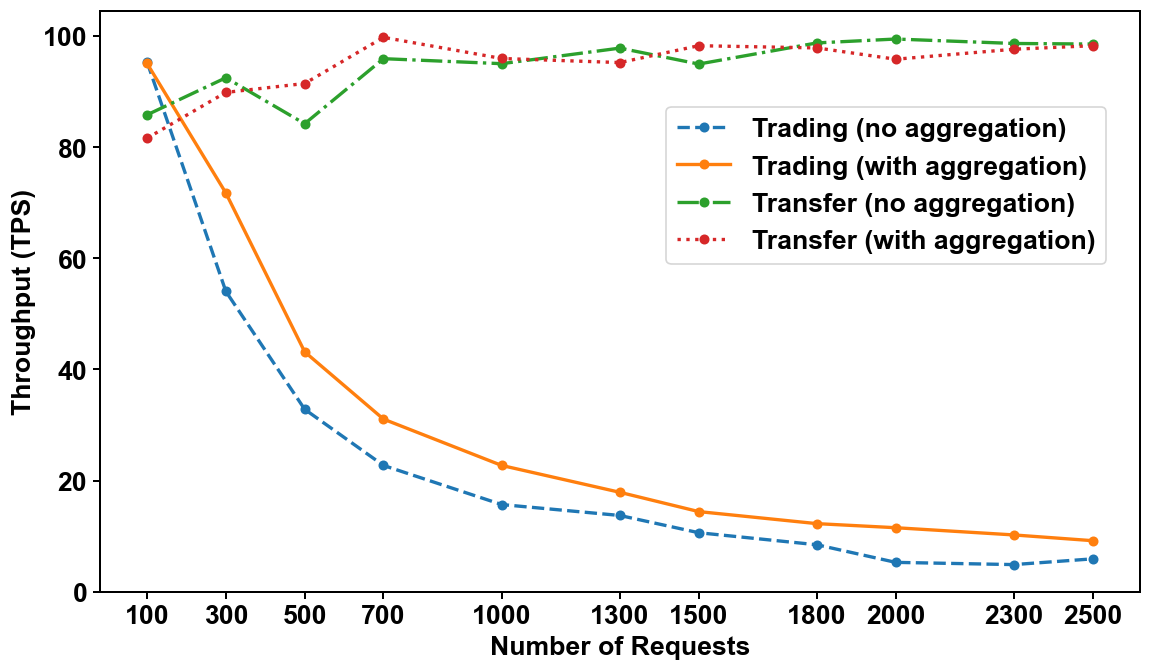

In [19]:
def plot_main_metric(metric, ylabel, output_name, *, y_bottom=0, yscale=None, legend_loc='best', legend_bbox=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for series, style in MAIN_STYLE.items():
        group = main_df[main_df['series'] == series].sort_values('request_size')
        if group.empty:
            continue
        ax.plot(
            group['request_size'],
            group[metric],
            label=series,
            linewidth=2.0,
            markersize=5,
            **style,
        )
    ax.set_xlabel('Number of Requests')
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(main_df['request_size'].unique()))
    if yscale is not None:
        ax.set_yscale(yscale)
    polish_axis(ax, y_bottom=y_bottom)
    legend_kwargs = {'frameon': True, 'loc': legend_loc, 'prop': LEGEND_PROP}
    if legend_bbox is not None:
        legend_kwargs['bbox_to_anchor'] = legend_bbox
    ax.legend(**legend_kwargs)
    fig.tight_layout()
    for suffix in ['png', 'svg', 'pdf']:
        fig.savefig(FIGURES_DIR / f'{output_name}.{suffix}', bbox_inches='tight')
    return fig, ax

fig, ax = plot_main_metric(
    'throughput_tps_mean',
    'Throughput (TPS)',
    'paper_main_throughput',
    legend_loc='center right',
    legend_bbox=(0.98, 0.70),
)

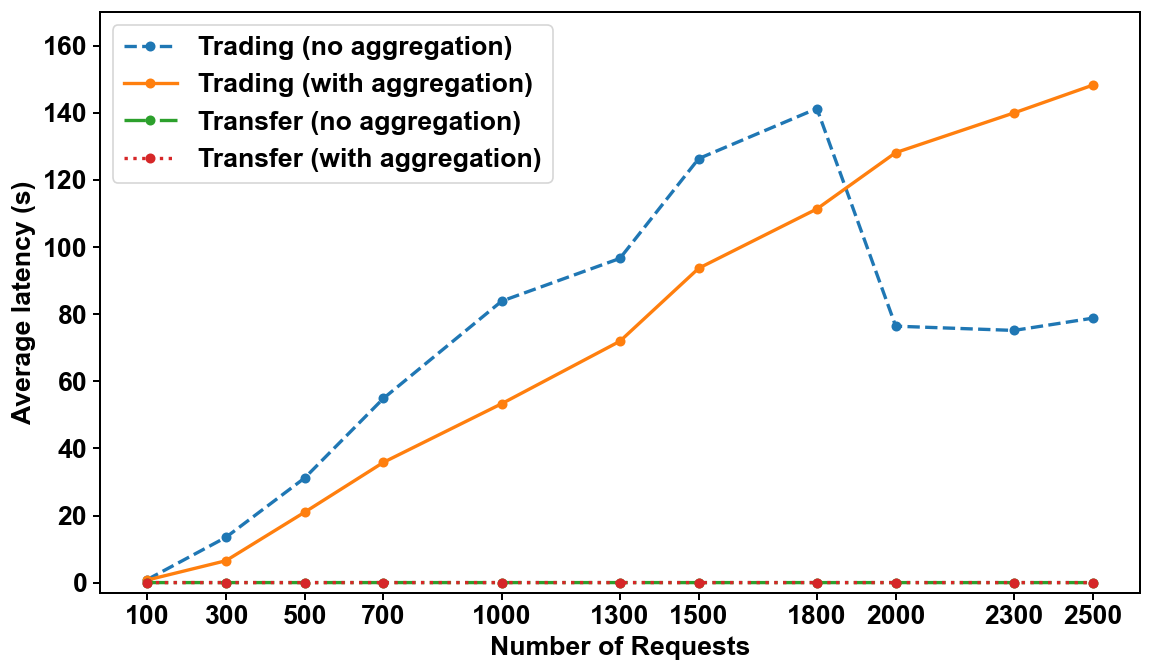

In [16]:
fig, ax = plot_main_metric(
    'avg_latency_s_mean',
    'Average latency (s)',
    'paper_main_latency',
    y_bottom=0,
    yscale=None,
    legend_loc='upper left',
)

# 强制控制 y 轴范围：让 0 在横轴上面一点点
ax.set_ylim(-3, 170)

fig.tight_layout()

for suffix in ['png', 'svg', 'pdf']:
    fig.savefig(FIGURES_DIR / f'paper_main_latency.{suffix}', bbox_inches='tight')

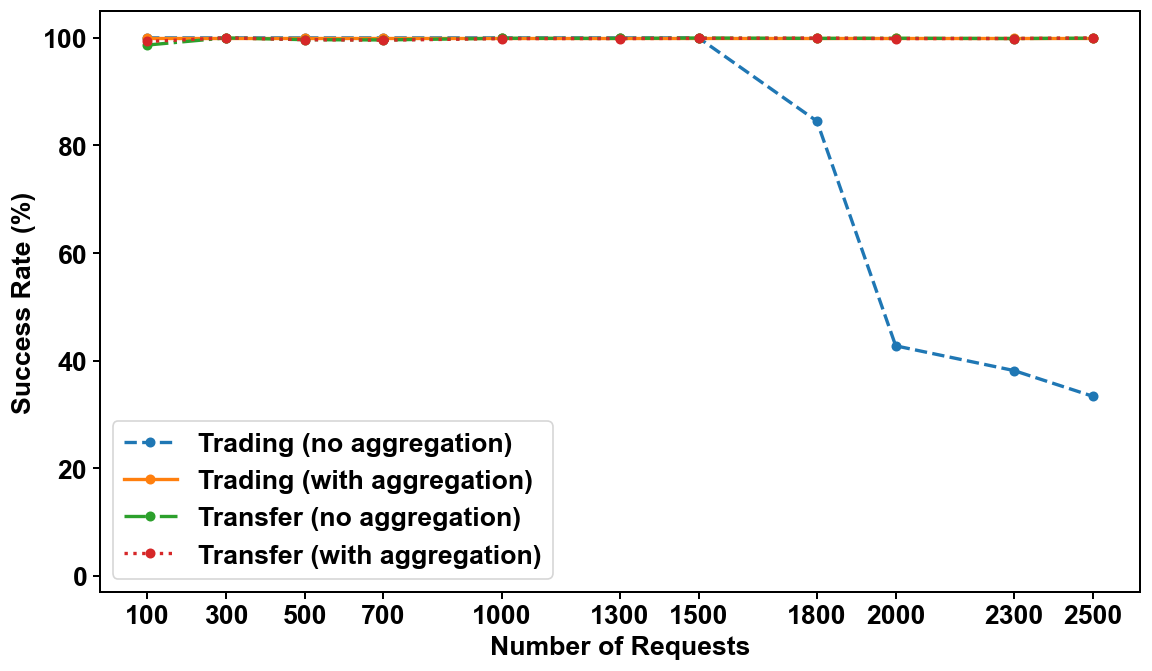

In [20]:
def plot_main_success_rate(output_name='paper_main_success_rate'):
    fig, ax = plt.subplots(figsize=(10, 6))
    for series, style in MAIN_STYLE.items():
        group = main_df[main_df['series'] == series].sort_values('request_size')
        if group.empty:
            continue
        ax.plot(
            group['request_size'],
            group['success_rate_mean'] * 100,
            label=series,
            linewidth=2.0,
            markersize=5,
            **style,
        )
    ax.set_xlabel('Number of Requests')
    ax.set_ylabel('Success Rate (%)')
    ax.set_xticks(sorted(main_df['request_size'].unique()))
    ax.set_ylim(-3, 105)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    polish_axis(ax, y_bottom=None)
    ax.legend(frameon=True, loc='lower left', prop=LEGEND_PROP)
    fig.tight_layout()
    for suffix in ['png', 'svg', 'pdf']:
        fig.savefig(FIGURES_DIR / f'{output_name}.{suffix}', bbox_inches='tight')
    return fig, ax

fig, ax = plot_main_success_rate()


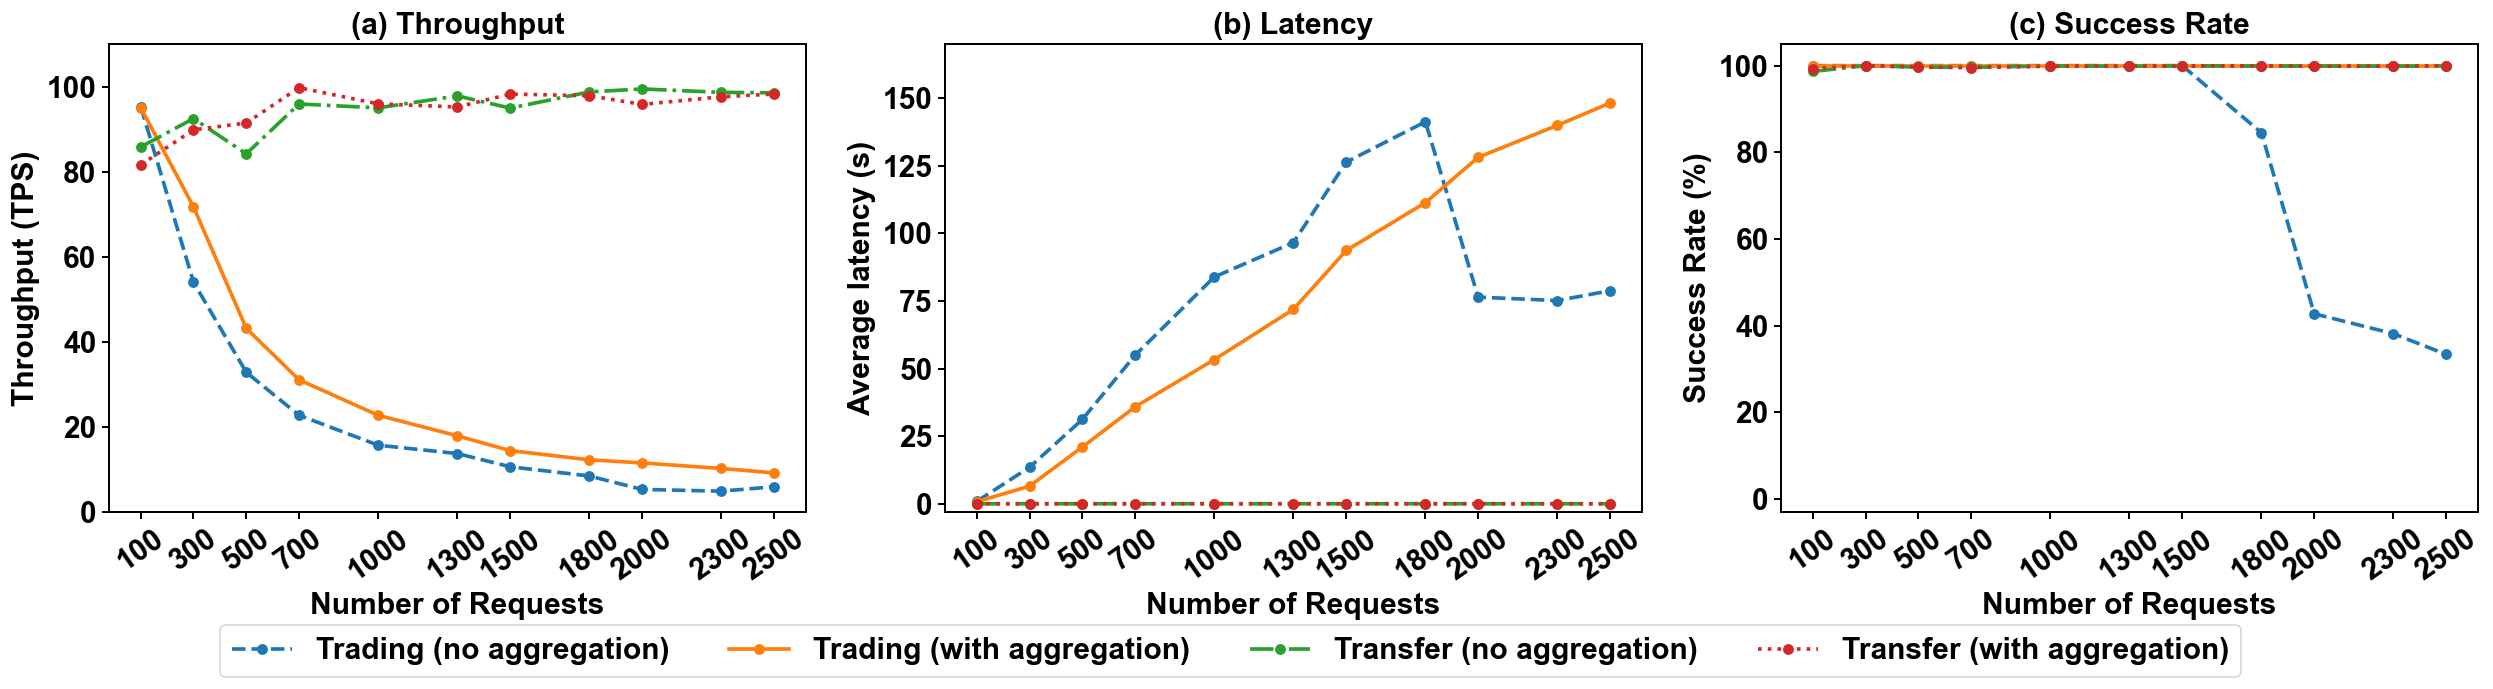

In [43]:
def plot_main_performance_combined(output_name='paper_main_performance_combined'):
    metrics = [
        (
            'throughput_tps_mean',
            'Throughput (TPS)',
            '(a) Throughput',
            None,
            None,
        ),
        (
            'avg_latency_s_mean',
            'Average latency (s)',
            '(b) Latency',
            (-3, 170),
            [0, 25, 50, 75, 100, 125, 150],
        ),
        (
            'success_rate_mean',
            'Success Rate (%)',
            '(c) Success Rate',
            (-3, 105),
            [0, 20, 40, 60, 80, 100],
        ),
    ]

    # 横轴显示所有刻度，所以图需要更宽、更高
    fig, axes = plt.subplots(1, 3, figsize=(21, 6.0))

    x_ticks = sorted(main_df['request_size'].unique())

    legend_handles = None
    legend_labels = None

    for ax, (metric, ylabel, title, ylim, yticks) in zip(axes, metrics):
        handles = []
        labels = []

        for series, style in MAIN_STYLE.items():
            group = main_df[main_df['series'] == series].sort_values('request_size')
            if group.empty:
                continue

            y = group[metric] * 100 if metric == 'success_rate_mean' else group[metric]

            line, = ax.plot(
                group['request_size'],
                y,
                label=series,
                linewidth=2.2,
                markersize=5.5,
                **style,
            )

            handles.append(line)
            labels.append(series)

        if legend_handles is None:
            legend_handles = handles
            legend_labels = labels

        # 标题、轴标签字体都至少 16
        ax.set_title(title, fontweight='bold', fontsize=18)
        ax.set_xlabel('Number of Requests', fontsize=18, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')

        # 横轴显示所有刻度
        ax.set_xticks(x_ticks)

        # 先 polish，再覆盖 tick 字体，避免 polish_axis 改回 rcParams
        polish_axis(ax, y_bottom=None)

        # tick 字体至少 16；横轴全部显示时建议旋转 35 度
        ax.tick_params(
            axis='x',
            labelrotation=35,
            labelsize=18,
            width=1.2,
            length=4,
        )
        ax.tick_params(
            axis='y',
            labelsize=18,
            width=1.2,
            length=4,
        )

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

        # 设置纵轴范围和刻度
        if ylim is not None:
            ax.set_ylim(*ylim)

        if yticks is not None:
            ax.set_yticks(yticks)

        # Throughput 自动增加 y 轴刻度
        if metric == 'throughput_tps_mean':
            y_max = main_df[metric].max()
            y_top = int(((y_max + 10) // 10 + 1) * 10)

            ax.set_ylim(0, y_top)
            ax.set_yticks(list(range(0, y_top + 1, 20)))

    # 图例一行展示，并靠近子图
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        frameon=True,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.000),
        ncol=len(legend_labels),
        prop={'size': 18, 'weight': 'bold'},
    )

    # 不建议这里用 tight_layout 后再留太小 bottom，否则图例容易贴近图片
    fig.tight_layout()

    # 子图间距调小；底部留白适中，让图例靠近图片
    fig.subplots_adjust(
        top=0.90,
        bottom=0.25,
        left=0.055,
        right=0.995,
        wspace=0.20,
    )

    for suffix in ['png', 'svg', 'pdf']:
        fig.savefig(
            FIGURES_DIR / f'{output_name}.{suffix}',
            bbox_inches='tight',
        )

    return fig, axes


fig, axes = plot_main_performance_combined()

## 4. Threshold Sensitivity Figures

In [ ]:
# Color palette from reference image
PALETTE = {
    'green': '#BCD6AD',
    'blue': '#91CEEC',
    'yellow': '#F4D8A2',
    'red': '#F09B9A',
}

SENSITIVITY_STYLE = {
    'Trading (no aggregation)': {
        'color': PALETTE['red'],
        'marker': 'D',
        'linestyle': '-',
    },
    'Threshold = 2000': {
        'color': PALETTE['blue'],
        'marker': 'o',
        'linestyle': '--',
    },
    'Threshold = 4000': {
        'color': PALETTE['yellow'],
        'marker': 's',
        'linestyle': '-.',
    },
    'Threshold = 6000': {
        'color': PALETTE['green'],
        'marker': '^',
        'linestyle': ':',
    },
}


def plot_sensitivity_metric(
    metric,
    ylabel,
    output_name,
    legend_loc='upper right',
    ylim=None,
    yticks=None,
):
    threshold_series = [
        'Threshold = 2000',
        'Threshold = 4000',
        'Threshold = 6000',
    ]

    threshold_value_map = {
        'Threshold = 2000': '2000',
        'Threshold = 4000': '4000',
        'Threshold = 6000': '6000',
    }

    baseline = sensitivity_df[
        sensitivity_df['series'] == 'Trading (no aggregation)'
    ].sort_values('request_size')

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4.2),   # 原来是 (15, 5.2)，这里压矮
        sharey=True,
    )

    for ax, series in zip(axes, threshold_series):
        group = sensitivity_df[
            sensitivity_df['series'] == series
        ].sort_values('request_size')

        if group.empty:
            continue

        threshold_value = threshold_value_map[series]

        line_base, = ax.plot(
            baseline['request_size'],
            baseline[metric],
            label='Trading (no aggregation)',
            linewidth=2.6,
            markersize=5.5,
            **SENSITIVITY_STYLE['Trading (no aggregation)'],
        )

        line_threshold, = ax.plot(
            group['request_size'],
            group[metric],
            label=f'Trading (Aggregation Threshold={threshold_value})',
            linewidth=2.6,
            markersize=5.5,
            **SENSITIVITY_STYLE[series],
        )

        ax.set_xlabel('Number of Requests')
        ax.set_xticks(sorted(sensitivity_df['request_size'].unique()))
        ax.tick_params(axis='x', labelrotation=35)

        polish_axis(ax)

        if ylim is not None:
            ax.set_ylim(*ylim)

        if yticks is not None:
            ax.set_yticks(yticks)

        legend = ax.legend(
            handles=[line_base, line_threshold],
            labels=[
                'Trading (no aggregation)',
                f'Trading (Aggregation Threshold={threshold_value})',
            ],
            frameon=True,
            loc=legend_loc,
            prop=LEGEND_PROP,
        )

        legend.get_frame().set_alpha(0.90)

    axes[0].set_ylabel(ylabel)

    fig.tight_layout()

    # 进一步压缩上下边距
    fig.subplots_adjust(
        top=0.96,
        bottom=0.20,
        left=0.055,
        right=0.995,
        wspace=0.13,
    )

    for suffix in ['svg', 'pdf']:
        fig.savefig(
            FIGURES_DIR / f'{output_name}.{suffix}',
            bbox_inches='tight',
        )

    return fig, axes

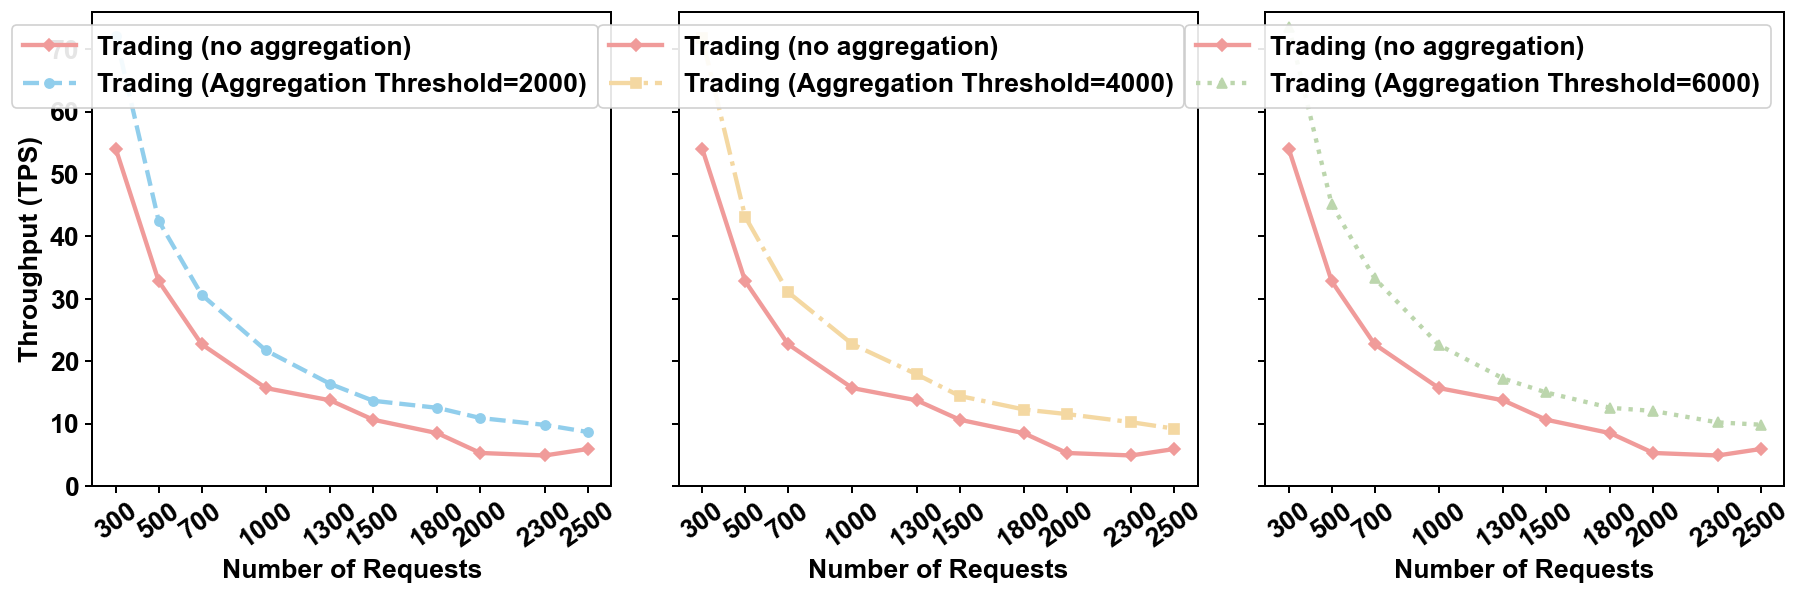

In [50]:
fig, ax = plot_sensitivity_metric(
    'throughput_tps_mean',
    'Throughput (TPS)',
    'paper_sensitivity_throughput',
    legend_loc='upper right',
    ylim=(0, 76),
    yticks=[0, 10, 20, 30, 40, 50, 60, 70],
)

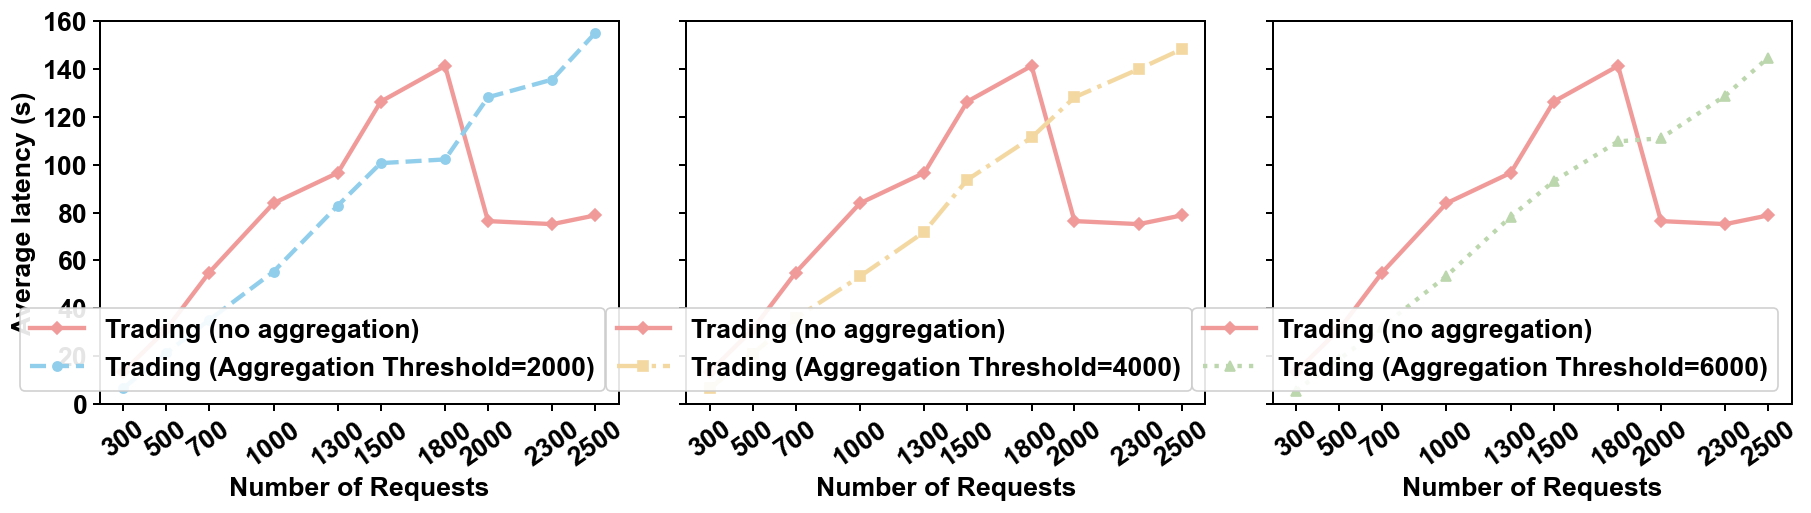

In [48]:
fig, ax = plot_sensitivity_metric(
    'avg_latency_s_mean',
    'Average latency (s)',
    'paper_sensitivity_latency',
    legend_loc='lower right',
    ylim=(0, 160),
    yticks=[0, 20, 40, 60, 80, 100, 120, 140, 160],
)

In [ ]:
def plot_sensitivity_combined(output_name='paper_sensitivity_combined'):
    threshold_series = [
        'Threshold = 2000',
        'Threshold = 4000',
        'Threshold = 6000',
    ]

    threshold_value_map = {
        'Threshold = 2000': '2000',
        'Threshold = 4000': '4000',
        'Threshold = 6000': '6000',
    }

    metric_rows = [
        {
            'metric': 'throughput_tps_mean',
            'ylabel': 'Throughput (TPS)',
            'row_title': '(a) Sensitivity analysis of throughput at different thresholds',
            'ylim': (0, 76),
            'yticks': [0, 10, 20, 30, 40, 50, 60, 70],
            'legend_loc': 'upper right',
        },
        {
            'metric': 'avg_latency_s_mean',
            'ylabel': 'Average latency (s)',
            'row_title': '(b) Sensitivity analysis of latency at different thresholds',
            'ylim': (0, 160),
            'yticks': [0, 20, 40, 60, 80, 100, 120, 140, 160],
            'legend_loc': 'lower right',
        },
    ]

    baseline = sensitivity_df[
        sensitivity_df['series'] == 'Trading (no aggregation)'
    ].sort_values('request_size')

    x_ticks = sorted(sensitivity_df['request_size'].unique())
    small_legend_prop = {'size': 12, 'weight': 'bold'}

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 8.2),
        sharex=False,
        sharey='row',
    )

    for row_idx, row in enumerate(metric_rows):
        for col_idx, series in enumerate(threshold_series):
            ax = axes[row_idx, col_idx]
            group = sensitivity_df[
                sensitivity_df['series'] == series
            ].sort_values('request_size')

            if group.empty:
                continue

            threshold_value = threshold_value_map[series]

            line_base, = ax.plot(
                baseline['request_size'],
                baseline[row['metric']],
                label='Trading (no aggregation)',
                linewidth=2.2,
                markersize=4.8,
                **SENSITIVITY_STYLE['Trading (no aggregation)'],
            )

            line_threshold, = ax.plot(
                group['request_size'],
                group[row['metric']],
                label=f'Trading (Aggregation Threshold={threshold_value})',
                linewidth=2.2,
                markersize=4.8,
                **SENSITIVITY_STYLE[series],
            )

            ax.set_xticks(x_ticks)
            ax.tick_params(axis='x', labelrotation=35, labelsize=12)
            ax.tick_params(axis='y', labelsize=12)
            polish_axis(ax)

            ax.set_ylim(*row['ylim'])
            ax.set_yticks(row['yticks'])
            ax.set_xlabel('Number of Requests', fontsize=13, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(row['ylabel'], fontsize=13, fontweight='bold')

            for label in ax.get_xticklabels() + ax.get_yticklabels():
                label.set_fontweight('bold')

            legend = ax.legend(
                handles=[line_base, line_threshold],
                labels=[
                    'Trading (no aggregation)',
                    f'Trading (Aggregation Threshold={threshold_value})',
                ],
                frameon=True,
                loc=row['legend_loc'],
                prop=small_legend_prop,
                handlelength=2.2,
                borderpad=0.35,
                labelspacing=0.35,
            )
            legend.get_frame().set_alpha(0.88)

    fig.text(
        0.5,
        0.985,
        metric_rows[0]['row_title'],
        ha='center',
        va='top',
        fontsize=16,
        fontweight='bold',
    )
    fig.text(
        0.5,
        0.485,
        metric_rows[1]['row_title'],
        ha='center',
        va='top',
        fontsize=16,
        fontweight='bold',
    )

    fig.subplots_adjust(
        top=0.925,
        bottom=0.105,
        left=0.055,
        right=0.995,
        hspace=0.58,
        wspace=0.13,
    )

    for suffix in ['png', 'svg', 'pdf']:
        fig.savefig(
            FIGURES_DIR / f'{output_name}.{suffix}',
            bbox_inches='tight',
        )

    return fig, axes


fig, axes = plot_sensitivity_combined()

